In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/home/sdu/Desktop/ExpreGaze").resolve()
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SRC_ROOT =", SRC_ROOT)

PROJECT_ROOT = /home/sdu/Desktop/ExpreGaze
SRC_ROOT = /home/sdu/Desktop/ExpreGaze/src


In [2]:
movienet_files_dir = PROJECT_ROOT / "data" / "raw" / "MovieNet" / "files"

ann = {p.stem for p in (movienet_files_dir / "annotation").glob("*.json")}
meta = {p.stem for p in (movienet_files_dir / "meta").glob("*.json")}
script = {p.stem for p in (movienet_files_dir / "script").glob("*.script")}
sub = {p.stem for p in (movienet_files_dir / "subtitle").glob("*.srt")}

print("annotation:", len(ann))
print("meta:", len(meta))
print("script:", len(script))
print("subtitle:", len(sub))
print()

print("script ∩ subtitle ∩ annotation ∩ meta:", len(script & sub & ann & meta))
print()

common = sorted(list(script & sub & ann & meta))[:20]
print("sample common ids:", common)

annotation: 8918
meta: 375359
script: 479
subtitle: 815

script ∩ subtitle ∩ annotation ∩ meta: 440

sample common ids: ['tt0032138', 'tt0035423', 'tt0038650', 'tt0047396', 'tt0048545', 'tt0049730', 'tt0052357', 'tt0056869', 'tt0056923', 'tt0058331', 'tt0061418', 'tt0061722', 'tt0062622', 'tt0063442', 'tt0065214', 'tt0065724', 'tt0066026', 'tt0067116', 'tt0068646', 'tt0070379']


In [3]:
movie_id = "tt0032138"
video_path = PROJECT_ROOT / "data" / "raw" / "Movie" / "The.Wizard.Of.Oz.1939.Bluray.1080p.DTS.2Audio.x264-CHD.mkv"

print("movie_id =", movie_id)
print("video_path exists =", video_path.exists())
print("movienet_files_dir exists =", movienet_files_dir.exists())

movie_id = tt0032138
video_path exists = True
movienet_files_dir exists = True


## shot-level table

In [4]:
from expregaze.movienet.shot_builder import (
    process_one_movie_to_shot_level,
    filter_usable_rows,
)

annotation_dir = movienet_files_dir / "annotation"
output_dir = PROJECT_ROOT / "data" / "interim" / "shot_level"

shot_df, csv_path, jsonl_path = process_one_movie_to_shot_level(
    movie_id=movie_id,
    annotation_dir=annotation_dir,
    output_dir=output_dir,
)

print("shot_df shape:", shot_df.shape)
print("csv_path:", csv_path)
print("jsonl_path:", jsonl_path)

usable_df = filter_usable_rows(shot_df)
print("usable_df shape:", usable_df.shape)

shot_df shape: (424, 13)
csv_path: /home/sdu/Desktop/ExpreGaze/data/interim/shot_level/tt0032138_shot_level.csv
jsonl_path: /home/sdu/Desktop/ExpreGaze/data/interim/shot_level/tt0032138_shot_level.jsonl
usable_df shape: (356, 13)


## shot-level dataframe

In [5]:
import pandas as pd

shot_csv = PROJECT_ROOT / "data" / "interim" / "shot_level" / f"{movie_id}_shot_level.csv"
shot_df = pd.read_csv(shot_csv)

print(shot_df.shape)
shot_df.head()

(424, 13)


,movie_id,story_id,story_description,shot_idx,shot_id,shot_start_time,shot_end_time,shot_start_time_hms,shot_end_time_hms,subtitle_sentences,subtitle_text,cast_pids,num_cast
0,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,3,shot_0003,125.583792,135.135000,00:02:05.584,00:02:15.135,"[""She isn't coming yet, Toto."", ""Did she hurt ...","She isn't coming yet, Toto. Did she hurt you? ...","[""nm0000023""]",1
1,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,4,shot_0004,135.176708,146.521375,00:02:15.177,00:02:26.521,"[""Aunt Em! Aunt Em!""]",Aunt Em! Aunt Em!,[],0
2,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,5,shot_0005,146.563083,183.433250,00:02:26.563,00:03:03.433,"[""Just listen to what Miss Gulch did to Toto--...",Just listen to what Miss Gulch did to Toto-- D...,"[""nm0000023"", ""nm0604656"", ""others""]",3
3,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,7,shot_0007,186.436250,188.730208,00:03:06.436,00:03:08.730,"[""ZEKE: How's she coming? HUNK: Take it easy.""]",ZEKE: How's she coming? HUNK: Take it easy.,"[""nm0355095"", ""nm0481618""]",2
4,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,8,shot_0008,188.771917,191.774917,00:03:08.772,00:03:11.775,"[""Ow!"", ""You got my finger!""]",Ow! You got my finger!,"[""nm0604656""]",1


## keyframes

In [13]:
from expregaze.vision.keyframes import extract_keyframes_for_movie

keyframe_dir = PROJECT_ROOT / "data" / "interim" / "keyframes" / f"shot_keyframes_{movie_id}"

extract_keyframes_for_movie(
    video_path=video_path,
    shot_df=shot_df,
    output_root=keyframe_dir,
    sample_ratios=(0.25, 0.5, 0.75),
)

print(keyframe_dir)

/home/sdu/Desktop/ExpreGaze/data/interim/keyframes/shot_keyframes_tt0032138


In [6]:
keyframe_dir = PROJECT_ROOT / "data" / "interim" / "keyframes" / f"shot_keyframes_{movie_id}"
shot_dirs = sorted([p for p in keyframe_dir.iterdir() if p.is_dir()])
print("num shot dirs:", len(shot_dirs))
print("first 5:", [p.name for p in shot_dirs[:5]])

num shot dirs: 421
first 5: ['shot_0003', 'shot_0004', 'shot_0005', 'shot_0007', 'shot_0008']


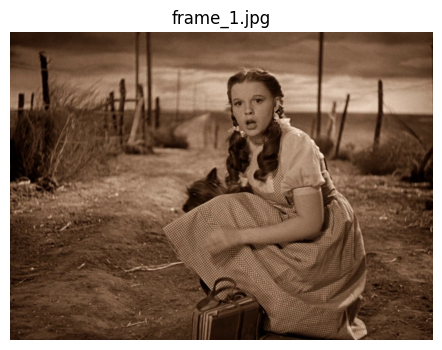

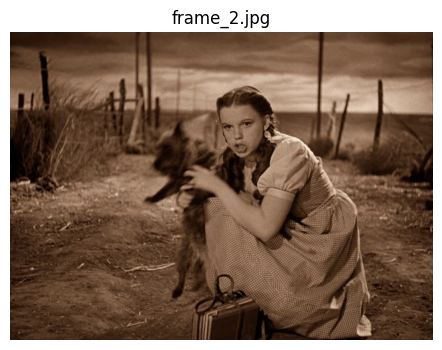

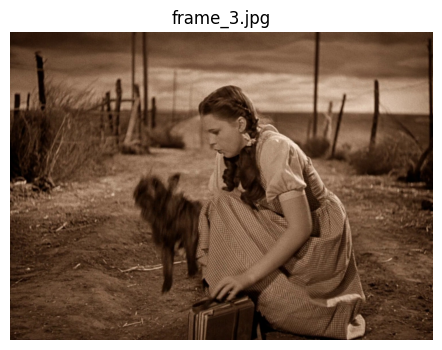

In [7]:
import cv2
import matplotlib.pyplot as plt

sample_paths = [
    keyframe_dir / "shot_0003" / "frame_1.jpg",
    keyframe_dir / "shot_0003" / "frame_2.jpg",
    keyframe_dir / "shot_0003" / "frame_3.jpg"
]

for p in sample_paths:
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(p.name)
    plt.axis("off")
    plt.show()

## face detection

In [9]:
from expregaze.vision.face_detector import create_yunet_detector, build_face_count_df

detector = create_yunet_detector(
    model_path = Path.home() / "models_yunet" / "face_detection_yunet_2023mar.onnx"
)

face_df = build_face_count_df(
    frame_root=keyframe_dir,
    detector=detector
)

print(face_df.shape)
display(face_df.head())
display(face_df["consensus_count"].value_counts(dropna=False))

(421, 9)


,shot_id,face_count_f1,face_count_f2,face_count_f3,consensus_count,count_range,mean_det_score,is_stable,is_candidate_1to3
0,shot_0003,1,1,1,1,0,0.904733,True,True
1,shot_0004,0,1,1,1,1,0.577660,True,True
2,shot_0005,2,1,2,2,1,0.896600,True,True
3,shot_0007,2,2,1,2,1,0.902692,True,True
4,shot_0008,0,0,1,0,1,0.221269,True,False


consensus_count
1     156
0      80
2      66
3      49
4      30
5       9
10      7
9       3
7       3
11      3
14      2
20      2
6       2
31      1
12      1
15      1
13      1
41      1
8       1
37      1
24      1
38      1
Name: count, dtype: int64

## strict candidate filtering

In [10]:
from expregaze.proxy.candidate_filter import add_valid_face_frames, filter_strict_face_candidates

face_df = add_valid_face_frames(face_df)
strict_face_df = filter_strict_face_candidates(face_df)

print("strict candidate shots:", len(strict_face_df))
display(strict_face_df.head())

strict candidate shots: 205


,shot_id,face_count_f1,face_count_f2,face_count_f3,consensus_count,count_range,mean_det_score,is_stable,is_candidate_1to3,num_frames_with_face
0,shot_0003,1,1,1,1,0,0.904733,True,True,3
1,shot_0005,2,1,2,2,1,0.896600,True,True,3
2,shot_0007,2,2,1,2,1,0.902692,True,True,3
3,shot_0009,2,2,2,2,0,0.920068,True,True,3
4,shot_0011,2,1,1,1,1,0.705256,True,True,3


In [11]:
shot_df["shot_id"] = shot_df["shot_idx"].apply(lambda x: f"shot_{int(x):04d}")

strict_candidate_df = shot_df.merge(
    strict_face_df,
    on="shot_id",
    how="inner"
).copy()

print(strict_candidate_df.shape)
display(strict_candidate_df.head())

(206, 22)


,movie_id,story_id,story_description,shot_idx,shot_id,shot_start_time,shot_end_time,shot_start_time_hms,shot_end_time_hms,subtitle_sentences,...,num_cast,face_count_f1,face_count_f2,face_count_f3,consensus_count,count_range,mean_det_score,is_stable,is_candidate_1to3,num_frames_with_face
0,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,3,shot_0003,125.583792,135.135000,00:02:05.584,00:02:15.135,"[""She isn't coming yet, Toto."", ""Did she hurt ...",...,1,1,1,1,1,0,0.904733,True,True,3
1,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,5,shot_0005,146.563083,183.433250,00:02:26.563,00:03:03.433,"[""Just listen to what Miss Gulch did to Toto--...",...,3,2,1,2,2,1,0.896600,True,True,3
2,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,7,shot_0007,186.436250,188.730208,00:03:06.436,00:03:08.730,"[""ZEKE: How's she coming? HUNK: Take it easy.""]",...,2,2,2,1,2,1,0.902692,True,True,3
3,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,9,shot_0009,191.816625,193.985458,00:03:11.817,00:03:13.985,"[""Get your finger out of the way.""]",...,1,2,2,2,2,0,0.920068,True,True,3
4,tt0032138,tt0032138_0000,Dorothy Gale is an orphaned teenager who live...,11,shot_0011,227.268708,240.406833,00:03:47.269,00:04:00.407,"[""Say, get in there before I make a dime bank ...",...,2,2,1,1,1,1,0.705256,True,True,3


## main subject extraction

In [12]:
from expregaze.vision.main_subject import build_main_subject_df

main_subject_df = build_main_subject_df(
    strict_candidate_df=strict_candidate_df,
    frame_root=keyframe_dir,
    detector=detector
)

print(main_subject_df.shape)
display(main_subject_df.head())

(205, 62)


,shot_idx,shot_id,subtitle_text,consensus_count,mean_det_score,f1_frame_path,f1_detected_faces,f1_main_found,f1_main_x,f1_main_y,...,f3_left_eye_x,f3_left_eye_y,f3_right_eye_x,f3_right_eye_y,f3_nose_x,f3_nose_y,f3_mouth_left_x,f3_mouth_left_y,f3_mouth_right_x,f3_mouth_right_y
0,3,shot_0003,"She isn't coming yet, Toto. Did she hurt you? ...",1,0.904733,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,1,True,775.958862,168.760757,...,690.378479,350.024628,722.006287,346.080719,697.086731,380.934937,714.878174,414.742889,737.782288,408.427765
1,5,shot_0005,Just listen to what Miss Gulch did to Toto-- D...,2,0.896600,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,2,True,369.978058,272.867004,...,357.989899,336.506134,386.448761,334.189148,389.939270,360.397339,361.559052,389.696289,385.191528,389.426300
2,7,shot_0007,ZEKE: How's she coming? HUNK: Take it easy.,2,0.902692,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,2,True,573.713989,183.445297,...,800.203735,188.535217,829.557007,189.955475,808.422852,206.643524,802.765320,221.162186,827.671265,221.877106
3,9,shot_0009,Get your finger out of the way.,2,0.920068,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,2,True,417.987854,123.166924,...,447.115601,209.857742,536.907043,198.588165,498.767273,254.643738,467.888763,297.310760,545.563232,287.378876
4,11,shot_0011,"Say, get in there before I make a dime bank ou...",1,0.705256,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,2,True,641.994934,374.101379,...,814.516113,70.879677,830.816040,70.446053,817.877319,84.760704,817.110535,97.114304,827.559692,96.532745


## stability + head direction

In [13]:
from expregaze.proxy.stability import add_stability_columns
from expregaze.vision.head_direction import add_framewise_head_direction, add_head_dir_consensus

main_subject_df = add_stability_columns(main_subject_df)
main_subject_df = add_framewise_head_direction(main_subject_df)
main_subject_df = add_head_dir_consensus(main_subject_df)

In [14]:
main_subject_df[[
    "shot_idx", "main_subject_center_std", "main_subject_stable",
    "head_dir_consensus", "head_dir_stable",
    "main_bbox_iou_mean", "main_bbox_stable"
]].head(20)

,shot_idx,main_subject_center_std,main_subject_stable,head_dir_consensus,head_dir_stable,main_bbox_iou_mean,main_bbox_stable
0,3,88.875393,True,left,True,0.195522,False
1,5,109.318855,True,right,True,0.076866,False
2,7,115.132911,True,left,True,0.221010,False
3,9,10.833709,True,front,True,0.853226,True
4,11,294.028112,False,left,True,0.000000,False
5,12,104.796752,True,left,True,0.085568,False
6,14,230.921503,False,left,True,0.000000,False
7,18,17.796522,True,right,True,0.806614,True
8,19,135.269333,False,right,True,0.054114,False
9,21,140.500928,False,left,True,0.151259,False


## final proxy candidates

In [15]:
from expregaze.proxy.stability import filter_final_proxy_candidates

final_proxy_df = filter_final_proxy_candidates(main_subject_df)
print(final_proxy_df.shape)
final_proxy_df.head()

(160, 74)


,shot_idx,shot_id,subtitle_text,consensus_count,mean_det_score,f1_frame_path,f1_detected_faces,f1_main_found,f1_main_x,f1_main_y,...,main_bbox_iou_mean,main_bbox_stable,f1_head_dir,f1_nose_offset_norm,f2_head_dir,f2_nose_offset_norm,f3_head_dir,f3_nose_offset_norm,head_dir_consensus,head_dir_stable
0,3,shot_0003,"She isn't coming yet, Toto. Did she hurt you? ...",1,0.904733,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,1,True,775.958862,168.760757,...,0.195522,False,left,-0.238612,left,-0.152641,left,-0.287900,left,True
1,5,shot_0005,Just listen to what Miss Gulch did to Toto-- D...,2,0.896600,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,2,True,369.978058,272.867004,...,0.076866,False,right,0.949761,front,0.007170,right,0.622651,right,True
2,7,shot_0007,ZEKE: How's she coming? HUNK: Take it easy.,2,0.902692,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,2,True,573.713989,183.445297,...,0.221010,False,front,0.004882,left,-0.337744,left,-0.219993,left,True
3,9,shot_0009,Get your finger out of the way.,2,0.920068,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,2,True,417.987854,123.166924,...,0.853226,True,front,0.051941,front,0.077542,front,0.075240,front,True
4,12,shot_0012,She ain't nothing to be afraid of. Have a litt...,1,0.892253,/home/sdu/Desktop/ExpreGaze/data/interim/keyfr...,1,True,766.303284,117.980438,...,0.085568,False,left,-1.073798,left,-0.326778,left,-0.973833,left,True


## merge shot meta + build tokens

In [16]:
from expregaze.proxy.token_builder import (
    map_interaction_type,
    infer_visual_target_coarse,
    duration_to_bin_v2,
    make_proxy_token,
)

shot_meta_df = shot_df[[
    "shot_id", "shot_idx", "shot_start_time", "shot_end_time", "subtitle_text"
]].drop_duplicates(subset=["shot_id"]).copy()

final_proxy_df = final_proxy_df.drop(
    columns=[c for c in ["shot_start_time", "shot_end_time", "subtitle_text",
                         "shot_start_time_x", "shot_start_time_y",
                         "shot_end_time_x", "shot_end_time_y",
                         "subtitle_text_x", "subtitle_text_y"]
             if c in final_proxy_df.columns],
    errors="ignore"
)

final_proxy_df = final_proxy_df.merge(
    shot_meta_df,
    on=["shot_id", "shot_idx"],
    how="left"
)

final_proxy_df["shot_duration"] = final_proxy_df["shot_end_time"] - final_proxy_df["shot_start_time"]
final_proxy_df["interaction_type"] = final_proxy_df["consensus_count"].apply(map_interaction_type)
final_proxy_df["visual_target_coarse"] = final_proxy_df.apply(infer_visual_target_coarse, axis=1)
final_proxy_df["duration_bin"] = final_proxy_df["shot_duration"].apply(duration_to_bin_v2)
final_proxy_df["proxy_token"] = final_proxy_df.apply(make_proxy_token, axis=1)

final_proxy_df[[
    "shot_idx", "shot_id", "subtitle_text",
    "interaction_type", "visual_target_coarse",
    "duration_bin", "proxy_token"
]].head(20)

,shot_idx,shot_id,subtitle_text,interaction_type,visual_target_coarse,duration_bin,proxy_token
0,3,shot_0003,"She isn't coming yet, Toto. Did she hurt you? ...",single,offscreen_left,DU_03,<SUBJ_MAIN> <SINGLE> <OFFSCREEN_LEFT> <DU_03>
1,5,shot_0005,Just listen to what Miss Gulch did to Toto-- D...,two_person,onscreen_person,DU_05,<SUBJ_MAIN> <TWO_PERSON> <ONSCREEN_PERSON> <DU...
2,7,shot_0007,ZEKE: How's she coming? HUNK: Take it easy.,two_person,onscreen_person,DU_02,<SUBJ_MAIN> <TWO_PERSON> <ONSCREEN_PERSON> <DU...
3,9,shot_0009,Get your finger out of the way.,two_person,front_center,DU_02,<SUBJ_MAIN> <TWO_PERSON> <FRONT_CENTER> <DU_02>
4,12,shot_0012,She ain't nothing to be afraid of. Have a litt...,single,offscreen_left,DU_02,<SUBJ_MAIN> <SINGLE> <OFFSCREEN_LEFT> <DU_02>
5,18,shot_0018,Someplace where there isn't any trouble.,single,offscreen_right,DU_02,<SUBJ_MAIN> <SINGLE> <OFFSCREEN_RIGHT> <DU_02>
6,23,shot_0023,If happy little bluebirds fly Beyond the rainb...,single,offscreen_right,DU_05,<SUBJ_MAIN> <SINGLE> <OFFSCREEN_RIGHT> <DU_05>
7,27,shot_0027,"Auntie Em! Uncle Henry! You won't let her, wil...",multi_person,onscreen_person,DU_05,<SUBJ_MAIN> <MULTI_PERSON> <ONSCREEN_PERSON> <...
8,33,shot_0033,Let's see. You're-- You're traveling in disgui...,two_person,onscreen_person,DU_05,<SUBJ_MAIN> <TWO_PERSON> <ONSCREEN_PERSON> <DU...
9,35,shot_0035,"Toto, that's not polite! We haven't been asked...",two_person,onscreen_person,DU_02,<SUBJ_MAIN> <TWO_PERSON> <ONSCREEN_PERSON> <DU...


## Statistical analysis

In [17]:
print(final_proxy_df["interaction_type"].value_counts(dropna=False))
print(final_proxy_df["visual_target_coarse"].value_counts(dropna=False))
print(final_proxy_df["duration_bin"].value_counts(dropna=False))

interaction_type
single          103
two_person       32
multi_person     25
Name: count, dtype: int64
visual_target_coarse
onscreen_person    46
offscreen_left     43
offscreen_right    36
front_center       35
Name: count, dtype: int64
duration_bin
DU_02    63
DU_03    42
DU_01    27
DU_04    15
DU_05    13
Name: count, dtype: int64


In [18]:
pd.crosstab(
    final_proxy_df["interaction_type"],
    final_proxy_df["visual_target_coarse"],
    margins=True
)

visual_target_coarse,front_center,offscreen_left,offscreen_right,onscreen_person,All
interaction_type,,,,,
multi_person,4,0,0,21,25
single,24,43,36,0,103
two_person,7,0,0,25,32
All,35,43,36,46,160


In [19]:
out_path = PROJECT_ROOT / "data" / "processed" / "final_proxy" / f"{movie_id}_final_proxy.csv"
final_proxy_df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(out_path)

/home/sdu/Desktop/ExpreGaze/data/processed/final_proxy/tt0032138_final_proxy.csv
